# Report 1: Analysis of energy and device usage throughout the day

The current report aims to use the provided data on energy and gas usage, as well as the data on the devices that were installed in the house to provide an overview of the consumption of gas and electricity throughout the day, as well as to analyse how device usage differs between day and night.


We can start by importing the home messages file and creating the "myhome" database. Then we can insert the files into the database and return the data from the database as a pandas dataframe.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from home_messages_db import *
db = HomeMessagesDB("sqlite:///myhome.db")
db.create_db()

First lets insert the files into the database

In [2]:
files = check_filepaths("P1e-*.csv.gz","P1e")
for file in files:
    db.insert_table_P1e(file)

C:\Users\miroe\OneDrive\Documents\Master stats\Essentials for data science\GA2025_07\data\P1e\P1e-2022-01-01-2022-05-07.csv.gz was already appended to table 'P1e'
C:\Users\miroe\OneDrive\Documents\Master stats\Essentials for data science\GA2025_07\data\P1e\P1e-2022-01-01-2022-07-10.csv.gz was already appended to table 'P1e'
C:\Users\miroe\OneDrive\Documents\Master stats\Essentials for data science\GA2025_07\data\P1e\P1e-2022-01-01-2022-09-22.csv.gz was already appended to table 'P1e'
C:\Users\miroe\OneDrive\Documents\Master stats\Essentials for data science\GA2025_07\data\P1e\P1e-2022-09-01-2022-10-07.csv.gz was already appended to table 'P1e'
C:\Users\miroe\OneDrive\Documents\Master stats\Essentials for data science\GA2025_07\data\P1e\P1e-2022-09-01-2022-10-16.csv.gz was already appended to table 'P1e'
C:\Users\miroe\OneDrive\Documents\Master stats\Essentials for data science\GA2025_07\data\P1e\P1e-2022-09-01-2022-10-19.csv.gz was already appended to table 'P1e'
C:\Users\miroe\OneDriv

And now fetch them and insert them into a pandas dataframe

In [3]:
Energy_usage = db.return_whole_table("P1e")
Energy_usage.head()

,epoch,Electricity_imported_T1,Electricity_imported_T2,Electricity_exported_T1,Electricity_exported_T2
0,1647612900,6506.377,5313.255,0.0,0.0
1,1647613800,6506.377,5313.516,0.0,0.0
2,1647614700,6506.377,5314.241,0.0,0.0
3,1647615600,6506.377,5314.800,0.0,0.0
4,1647616500,6506.377,5314.933,0.0,0.0


The First kind of analysis is about the energy usage throughout the day, which means we first need to convert the epochs (so unix time) into datetime and extract the times seperately from the whole date.

In [4]:
Energy_usage["date"] = pd.to_datetime(Energy_usage.loc[:,"epoch"]*10**9).dt.date
Energy_usage["time"] = pd.to_datetime(Energy_usage.loc[:,"epoch"]*10**9).dt.strftime("%H:%M")
Energy_usage.head()

,epoch,Electricity_imported_T1,Electricity_imported_T2,Electricity_exported_T1,Electricity_exported_T2,date,time
0,1647612900,6506.377,5313.255,0.0,0.0,2022-03-18,14:15
1,1647613800,6506.377,5313.516,0.0,0.0,2022-03-18,14:30
2,1647614700,6506.377,5314.241,0.0,0.0,2022-03-18,14:45
3,1647615600,6506.377,5314.800,0.0,0.0,2022-03-18,15:00
4,1647616500,6506.377,5314.933,0.0,0.0,2022-03-18,15:15


Since the energy usage columns indicate the overall energy usage for low and high cost hours we need to create a new column that checks the usage at each timepoint to the previous timepoint for both columns and then takes the sum of those two values as the consumption for that period.

In [5]:
Energy_usage["Usage"] = Energy_usage.loc[:,"Electricity_imported_T1"].diff() + Energy_usage.loc[:,"Electricity_imported_T2"].diff()
Energy_usage.head()

,epoch,Electricity_imported_T1,Electricity_imported_T2,Electricity_exported_T1,Electricity_exported_T2,date,time,Usage
0,1647612900,6506.377,5313.255,0.0,0.0,2022-03-18,14:15,NaN
1,1647613800,6506.377,5313.516,0.0,0.0,2022-03-18,14:30,0.261
2,1647614700,6506.377,5314.241,0.0,0.0,2022-03-18,14:45,0.725
3,1647615600,6506.377,5314.800,0.0,0.0,2022-03-18,15:00,0.559
4,1647616500,6506.377,5314.933,0.0,0.0,2022-03-18,15:15,0.133


Now we can use a lineplot to see how energy consumption varies roughly throughout the day. The red lines mark a shift from high-cost to low-cost hours / vice versa

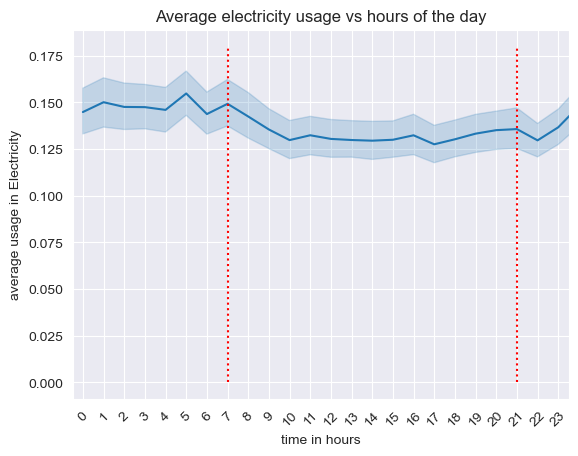

In [6]:
ax = sns.lineplot(Energy_usage, x = "time", y = "Usage", estimator= "mean")
plt.xticks(np.arange(0,24, step = 1), rotation = 45, labels = range(0,24,1))
plt.xlim(-0.5, 23.5)
plt.vlines(x = [7,21], ymin = 0, ymax= 0.18, linestyles= "dotted", color = "red")
ax.set(xlabel = "time in hours", ylabel = "average usage in Electricity", title = "Average electricity usage vs hours of the day")
plt.show()

Looking at the plot, there is not a huge difference between the different hours of the day. It does look like more energy is used during the low-cost hours than the high-cost ones, which intuitively does make sense, as this saves money.